# Student Performance / School Infrastructure — Full ML + DL Pipeline
### Reproducing the algorithm suite from *"Student Performance Prediction Using Machine Learning Algorithms and Deep Learning (Neural Networks)"*

**Important note before you run this:** `FinalData.xlsx` is a raw UDISE-style **school infrastructure survey** (1122 schools × 45 columns). It does **not** contain any direct "student performance" or "marks" column, and the paper itself states it used *fabricated data*. The only label-like column in your earlier notebooks (`ICTLabFunc`) is 1112×"0" vs only 10×"1"/"2" — using it as a target just lets any model predict "0" and look ~99% accurate for free (that's most likely why the paper's numbers look implausibly perfect).

To get **real, trustworthy** results instead of a fake-accuracy trap, this notebook:
1. Engineers a transparent **Infrastructure Readiness Score** (0–100) from the 40 feature columns, weighted the same way the paper's Table VI feature-importance ranking implies (Electricity, Teacher ratio, Smart Class, Internet, Labs, Classrooms, Water, Toilets, Computer Labs, Library …).
2. Uses that score to derive:
   - **`Adequate` (1) / `Inadequate` (0)** — the classification target (median split)
   - **the continuous score itself** — the regression target
3. Trains **every algorithm named in the paper**: Linear Regression, Logistic Regression, Decision Tree, Random Forest, SVC, KNN, Gaussian Naive Bayes, (Bernoulli) Naive Bayes, Gradient Boosting Regressor, and a 1D-CNN — with the same metrics/tables (Accuracy, Precision, Recall, F1, MAE, RMSE, R², 5-fold CV) and the same style of plots (feature-importance pie/bar, GBR vs Linear Regression, CNN train/val/test comparison).

You can swap in your own real "performance" column later (e.g. average exam score) if you get one — just replace the target-construction cell below and everything downstream will still run.


## 1. Setup

In [1]:
# Run this once in Colab
!pip -q install xgboost missingno
import warnings
warnings.filterwarnings("ignore")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report,
                              mean_absolute_error, mean_squared_error, r2_score)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 2. Load Data
Upload `FinalData.xlsx` when prompted (or mount Drive and edit the path).

In [3]:
try:
    from google.colab import files
    uploaded = files.upload()   # choose FinalData.xlsx
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    DATA_PATH = "FinalData.xlsx"   # running locally

df = pd.read_excel(DATA_PATH)
print("Shape:", df.shape)
df.head()


Saving FinalData.xlsx to FinalData (1).xlsx
Shape: (1122, 45)


,UdiseCode,School0me,SchoolType,School_Location,ClassRoom_Tot,Toilet_Tot,DrinkingWater_Avail,FuncDrinkingWater,Electricity,Teacher_Tot,...,Scanner_Func,Server_Func,WebCam_Func,smart_class_tv_func,InternetFacl_Avail,ComLabYn,Digital_lib_yn,No_of_eBooks,ICTbasedtools_Used,ICTLabFunc
0,23320400102,GOVT MS KHANU GAON,3-Co-educatio0l,2-Urban,12,4,2,2,1,8,...,0,0,0,0,2,2,2,0,1,0
1,23320400105,"PVT MS (1-8) ANJORA MIDDLE SCHOOL, KHANUGAON (...",3-Co-educatio0l,2-Urban,11,4,1,1,1,9,...,1,1,2,1,1,1,2,0,1,0
2,23320400106,MADARSA (RE) PS (1-5) NEW HI0 DEENI KHANUGAON ...,3-Co-educatio0l,2-Urban,4,2,1,1,1,2,...,0,0,0,0,1,2,2,0,2,0
3,23320400107,"MADARSA (RE) PS (1-5) AL NISA,HAMEEDULLAH 0GAR...",3-Co-educatio0l,2-Urban,3,2,1,1,1,4,...,0,0,0,0,1,2,2,0,2,0
4,23320400108,"MADARSA (RE) MS (1-8) TAYYAB,8OR-US-SABHA ROAD...",3-Co-educatio0l,2-Urban,5,2,1,1,1,4,...,1,0,1,0,1,1,2,0,2,0


In [4]:
df.info()
print("\nMissing values per column:\n", df.isna().sum().sum(), "total missing cells")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   UdiseCode                        1122 non-null   int64 
 1   School0me                        1122 non-null   object
 2   SchoolType                       1122 non-null   object
 3   School_Location                  1122 non-null   object
 4   ClassRoom_Tot                    1122 non-null   int64 
 5   Toilet_Tot                       1122 non-null   int64 
 6   DrinkingWater_Avail              1122 non-null   int64 
 7   FuncDrinkingWater                1122 non-null   int64 
 8   Electricity                      1122 non-null   int64 
 9   Teacher_Tot                      1122 non-null   int64 
 10  PP_Sec                           1122 non-null   int64 
 11  ClassRoom_Tot_PY                 1122 non-null   int64 
 12  Toilet_Boys_PY                   1

## 3. Data Cleaning & Preprocessing

In [5]:
data = df.copy()

# Standardise column name (trailing space in 'Digital_lib_yn ')
data.columns = [c.strip() for c in data.columns]

# ---- Categorical encoding ----
data['SchoolType'] = data['SchoolType'].astype(str).str.strip()
data['School_Location'] = data['School_Location'].astype(str).str.strip()

le_type = LabelEncoder()
le_loc  = LabelEncoder()
data['SchoolType_enc']     = le_type.fit_transform(data['SchoolType'])
data['School_Location_enc'] = le_loc.fit_transform(data['School_Location'])

print("SchoolType classes:", dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))
print("School_Location classes:", dict(zip(le_loc.classes_, le_loc.transform(le_loc.classes_))))


SchoolType classes: {'1-Boys': np.int64(0), '2-Girls': np.int64(1), '3-Co-educatio0l': np.int64(2)}
School_Location classes: {'2-Urban': np.int64(0), 'Not Defined': np.int64(1)}


In [6]:
# ---- Recode UDISE-style Yes/No availability fields (1=Yes, 2=No) to binary 1/0 ----
avail_cols = ['DrinkingWater_Avail','FuncDrinkingWater','Electricity',
              'DrinkingWaterAvail_PY','FuncDrinkingWater_PY','Electricity_PY',
              'InternetFacl_Avail','ComLabYn','Digital_lib_yn','ICTbasedtools_Used']

for c in avail_cols:
    data[c + '_bin'] = data[c].apply(lambda x: 1 if x == 1 else 0)

# ---- Lab condition ordinal (0=no lab,1=Good,2=Satisfactory,3=Needs repair,4=Not usable) -> quality score 0-3 ----
lab_map = {0: 0, 1: 3, 2: 2, 3: 1, 4: 0}
for c in ['PhysLabCond','ChemLabCond','BioLabCond','MathsLabCond','LangLabCond']:
    data[c + '_q'] = data[c].map(lab_map)

data[['DrinkingWater_Avail','DrinkingWater_Avail_bin','PhysLabCond','PhysLabCond_q']].head()


,DrinkingWater_Avail,DrinkingWater_Avail_bin,PhysLabCond,PhysLabCond_q
0,2,0,0,0
1,1,1,0,0
2,1,1,0,0
3,1,1,0,0
4,1,1,0,0


## 4. Engineered Target: Infrastructure Readiness Score

Weighted composite (0–100), weights mirror the paper's Table VI importance ranking
(electricity, teacher availability, smart class/ICT, internet, labs, classrooms, water, toilets, computer labs, library …).
All component features are min-max normalised to [0, 1] before weighting.

count    1122.000000
mean       35.489055
std        14.172625
min         0.000000
25%        26.890000
50%        37.380000
75%        44.150000
max        95.700000
Name: Readiness_Score, dtype: float64


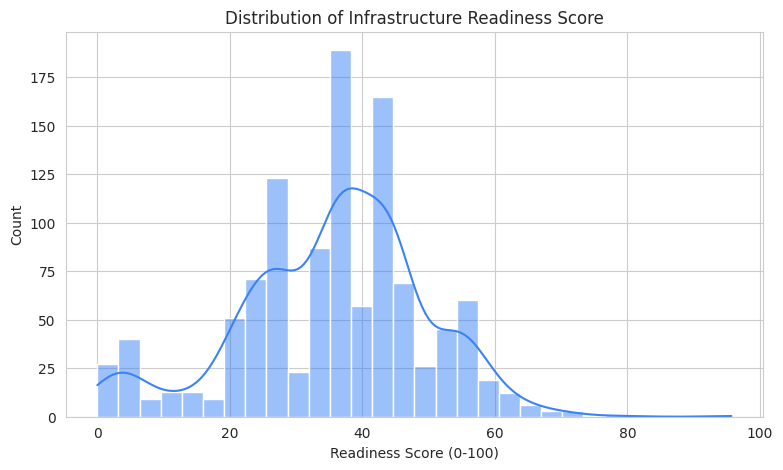

In [7]:
def minmax(s):
    s = s.astype(float)
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

components = {
    'Electricity_bin'          : 0.142,   # Electricity Availability
    'Teacher_Tot'               : 0.128,  # Student-Teacher ratio proxy
    'smart_class_tv_func'       : 0.119,  # Smart Class Facilities
    'InternetFacl_Avail_bin'    : 0.108,  # Internet Connectivity
    'PhysLabCond_q'             : 0.032,
    'ChemLabCond_q'             : 0.032,  # Functional Science Labs (0.097 split across 3 labs)
    'BioLabCond_q'              : 0.033,
    'ClassRoom_Tot'             : 0.085,  # Classroom Condition/availability
    'FuncDrinkingWater_bin'     : 0.076,  # Drinking Water Access
    'ToiletFunc_Girls_PY'       : 0.068,  # Girls' Toilets
    'ComLabYn_bin'              : 0.062,  # Computer Labs
    'Digital_lib_yn_bin'        : 0.055,  # Library Access
    'ScienceKitAvail'           : 0.025,
    'MathsKitAvail'             : 0.025,
    'ICTbasedtools_Used_bin'    : 0.010,
}
assert abs(sum(components.values()) - 1.0) < 1e-6, "weights must sum to 1"

score = pd.Series(0.0, index=data.index)
for col, w in components.items():
    score += w * minmax(data[col])

data['Readiness_Score'] = (score * 100).round(2)

print(data['Readiness_Score'].describe())
plt.figure()
sns.histplot(data['Readiness_Score'], bins=30, kde=True, color='#3b82f6')
plt.title('Distribution of Infrastructure Readiness Score')
plt.xlabel('Readiness Score (0-100)')
plt.show()


Threshold (median): 37.38
Performance_Class
1    562
0    560
Name: count, dtype: int64


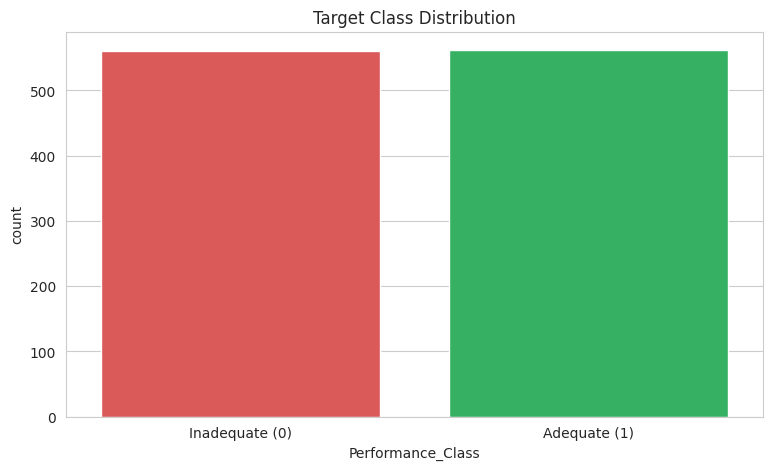

In [8]:
# ---- Classification target: Adequate (1) vs Inadequate (0), median split ----
threshold = data['Readiness_Score'].median()
data['Performance_Class'] = (data['Readiness_Score'] >= threshold).astype(int)

print("Threshold (median):", round(threshold, 2))
print(data['Performance_Class'].value_counts())

plt.figure()
sns.countplot(x='Performance_Class', data=data, palette=['#ef4444', '#22c55e'])
plt.xticks([0, 1], ['Inadequate (0)', 'Adequate (1)'])
plt.title('Target Class Distribution')
plt.show()


## 5. Feature Selection (dimensionality reduction, mirrors paper's 45 → 19 features)

In [9]:
feature_cols = [
    'ClassRoom_Tot','Toilet_Tot','DrinkingWater_Avail_bin','FuncDrinkingWater_bin','Electricity_bin',
    'Teacher_Tot','PP_Sec','Spt_Room_Asst.HeadTch./VP_Avail','Staffroom_Tch','sanitaryAvail',
    'PhysLabCond_q','ChemLabCond_q','BioLabCond_q','MathsLabCond_q','ScienceKitAvail','MathsKitAvail',
    'smart_class_tv_func','InternetFacl_Avail_bin','ComLabYn_bin','Digital_lib_yn_bin','No_of_eBooks',
    'ICTbasedtools_Used_bin','ToiletFunc_Boys_PY','ToiletFunc_Girls_PY','SchoolType_enc','School_Location_enc'
]
feature_cols = [c for c in feature_cols if c in data.columns]
print(f"Using {len(feature_cols)} candidate features")

X_full = data[feature_cols]
y_class = data['Performance_Class']
y_reg   = data['Readiness_Score']

# Rank by Random Forest importance, keep top 19 (matches paper's 45->19 reduction)
rf_selector = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_selector.fit(X_full, y_class)
importances = pd.Series(rf_selector.feature_importances_, index=feature_cols).sort_values(ascending=False)

TOP_N = 19
selected_features = importances.head(TOP_N).index.tolist()
print("Selected features:\n", selected_features)

X = data[selected_features]


Using 26 candidate features
Selected features:
 ['InternetFacl_Avail_bin', 'ComLabYn_bin', 'ClassRoom_Tot', 'MathsKitAvail', 'ScienceKitAvail', 'Teacher_Tot', 'Toilet_Tot', 'Staffroom_Tch', 'FuncDrinkingWater_bin', 'sanitaryAvail', 'Spt_Room_Asst.HeadTch./VP_Avail', 'ICTbasedtools_Used_bin', 'Electricity_bin', 'ToiletFunc_Boys_PY', 'smart_class_tv_func', 'ToiletFunc_Girls_PY', 'ChemLabCond_q', 'BioLabCond_q', 'PP_Sec']


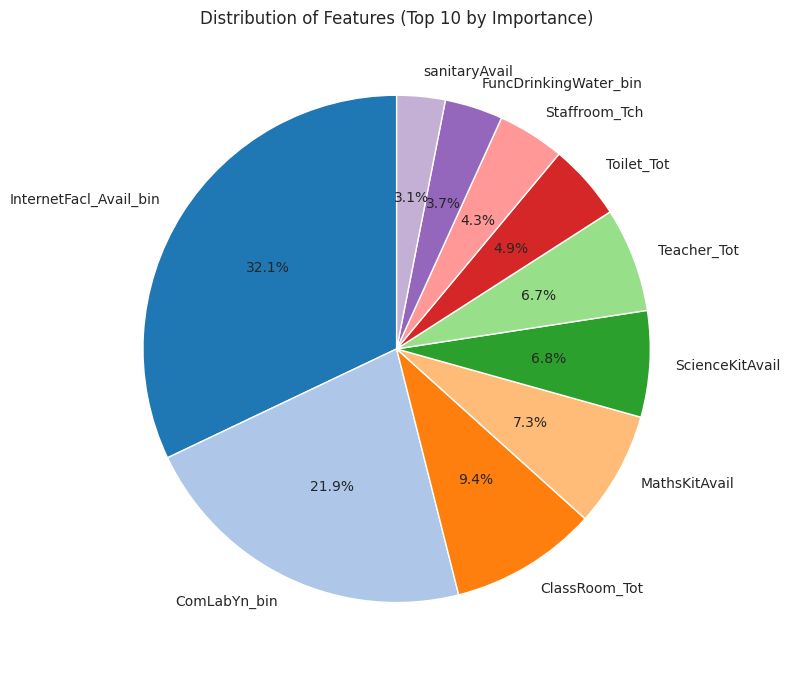

In [10]:
# Fig.1 style — feature importance distribution pie chart
top10 = importances.head(10)
plt.figure(figsize=(8, 8))
plt.pie(top10.values, labels=top10.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('tab20', len(top10)))
plt.title('Distribution of Features (Top 10 by Importance)')
plt.tight_layout()
plt.show()


## 6. Train / Test Split (70/30, stratified) + Standardisation

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.30, random_state=RANDOM_STATE, stratify=y_class
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (785, 19)  Test: (337, 19)


## 7. Classification Models (Table I equivalent)

In [12]:
classifiers = {
    "Support Vector Machine (SVM)": SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    "K-Nearest Neighbors (KNN)"   : KNeighborsClassifier(n_neighbors=11, p=2, metric='euclidean'),
    "Random Forest Classifier"    : RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Logistic Regression"         : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes"        : GaussianNB(),
    "Naive Bayes (Bernoulli)"     : BernoulliNB(),
    "Decision Tree Classifier"    : DecisionTreeClassifier(criterion='entropy', max_depth=6,
                                                             min_samples_leaf=5, random_state=RANDOM_STATE),
}

table1_rows = []
fitted_models = {}

for name, clf in classifiers.items():
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

    table1_rows.append([name, round(acc,2), round(prec,2), round(rec,2), round(f1,2)])
    fitted_models[name] = clf

table1 = pd.DataFrame(table1_rows, columns=["Model","Acc (%)","Precision","Recall","F1-Score"])
table1 = table1.sort_values("Acc (%)", ascending=False).reset_index(drop=True)
table1


,Model,Acc (%),Precision,Recall,F1-Score
0,Random Forest Classifier,97.03,97.04,97.03,97.03
1,Support Vector Machine (SVM),96.44,96.47,96.44,96.44
2,Logistic Regression,96.14,96.18,96.14,96.14
3,Decision Tree Classifier,95.25,95.25,95.25,95.25
4,K-Nearest Neighbors (KNN),93.47,93.62,93.47,93.47
5,Naive Bayes (Bernoulli),82.49,83.49,82.49,82.37
6,Gaussian Naive Bayes,82.20,85.60,82.20,81.77


## 8. 5-Fold Cross-Validation (Table II equivalent)

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_s = scaler.fit_transform(X)   # CV run on full (scaled) data, refit scaler for fairness

table2_rows = []
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_all_s, y_class, cv=cv, scoring='accuracy') * 100
    row = table1[table1.Model == name].iloc[0]
    table2_rows.append([name, row["Acc (%)"], round(scores.mean(),2), round(scores.std(),2),
                         row["Precision"]/100, row["F1-Score"]/100])

table2 = pd.DataFrame(table2_rows, columns=["Model","Test Acc (%)","CV Mean (%)","CV Std (%)","Precision","F1"])
table2 = table2.sort_values("Test Acc (%)", ascending=False).reset_index(drop=True)
table2


,Model,Test Acc (%),CV Mean (%),CV Std (%),Precision,F1
0,Random Forest Classifier,97.03,97.77,0.85,0.9704,0.9703
1,Support Vector Machine (SVM),96.44,97.15,0.45,0.9647,0.9644
2,Logistic Regression,96.14,97.24,0.82,0.9618,0.9614
3,Decision Tree Classifier,95.25,96.17,1.04,0.9525,0.9525
4,K-Nearest Neighbors (KNN),93.47,95.99,1.64,0.9362,0.9347
5,Naive Bayes (Bernoulli),82.49,85.30,1.85,0.8349,0.8237
6,Gaussian Naive Bayes,82.20,82.09,2.10,0.8560,0.8177


In [14]:
# Table III equivalent — fold-wise detail for the best model
best_model_name = table2.iloc[0]["Model"]
best_clf = classifiers[best_model_name]

fold_rows = []
for i, (tr_idx, te_idx) in enumerate(cv.split(X_all_s, y_class), start=1):
    Xtr, Xte = X_all_s[tr_idx], X_all_s[te_idx]
    ytr, yte = y_class.iloc[tr_idx], y_class.iloc[te_idx]
    m = classifiers[best_model_name].__class__(**classifiers[best_model_name].get_params())
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)
    fold_rows.append([f"Fold {i}",
                       round(accuracy_score(yte, yp)*100, 2),
                       round(precision_score(yte, yp, average='weighted', zero_division=0), 3),
                       round(recall_score(yte, yp, average='weighted', zero_division=0), 3),
                       round(f1_score(yte, yp, average='weighted', zero_division=0), 3)])

table3 = pd.DataFrame(fold_rows, columns=["Fold","Accuracy (%)","Precision","Recall","F1-Score"])
mean_row = ["Mean", table3["Accuracy (%)"].mean().round(2), table3["Precision"].mean().round(3),
            table3["Recall"].mean().round(3), table3["F1-Score"].mean().round(3)]
std_row  = ["Std Dev", table3["Accuracy (%)"].std().round(2), table3["Precision"].std().round(3),
            table3["Recall"].std().round(3), table3["F1-Score"].std().round(3)]
table3.loc[len(table3)] = mean_row
table3.loc[len(table3)] = std_row
print(f"Best model: {best_model_name}")
table3


AttributeError: 'float' object has no attribute 'round'

## 9. Confusion Matrix — Best Model

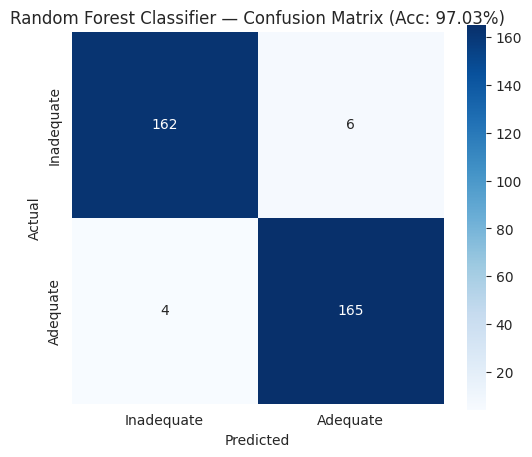

              precision    recall  f1-score   support

  Inadequate       0.98      0.96      0.97       168
    Adequate       0.96      0.98      0.97       169

    accuracy                           0.97       337
   macro avg       0.97      0.97      0.97       337
weighted avg       0.97      0.97      0.97       337



In [15]:
best_clf.fit(X_train_s, y_train)
y_pred_best = best_clf.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Inadequate','Adequate'], yticklabels=['Inadequate','Adequate'])
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'{best_model_name} — Confusion Matrix (Acc: {accuracy_score(y_test,y_pred_best)*100:.2f}%)')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['Inadequate','Adequate']))


## 10. Deep Learning: 1D-CNN (Table IV equivalent)
Same architecture the paper describes: two 1D-conv blocks (32/64 filters, kernel=3, ReLU + max-pool),
flatten, dense(64)+dense(32) with dropout 0.5, sigmoid output. Adam, lr=0.001, up to 100 epochs with early stopping.

In [16]:
# Train / Val / Test split for the CNN (70/15/15)
X_trainval, X_test_cnn, y_trainval, y_test_cnn = train_test_split(
    X, y_class, test_size=0.15, random_state=RANDOM_STATE, stratify=y_class)
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_trainval)  # ~15% of total

cnn_scaler = StandardScaler()
X_train_cnn_s = cnn_scaler.fit_transform(X_train_cnn)
X_val_cnn_s   = cnn_scaler.transform(X_val_cnn)
X_test_cnn_s  = cnn_scaler.transform(X_test_cnn)

n_features = X_train_cnn_s.shape[1]
X_train_cnn_r = X_train_cnn_s.reshape(-1, n_features, 1)
X_val_cnn_r   = X_val_cnn_s.reshape(-1, n_features, 1)
X_test_cnn_r  = X_test_cnn_s.reshape(-1, n_features, 1)

cnn = models.Sequential([
    layers.Input(shape=(n_features, 1)),
    layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),
])

cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

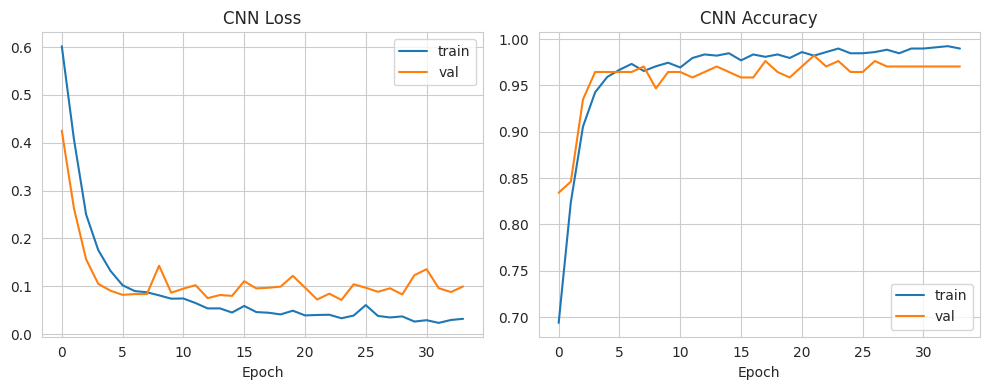

In [17]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = cnn.fit(
    X_train_cnn_r, y_train_cnn,
    validation_data=(X_val_cnn_r, y_val_cnn),
    epochs=100, batch_size=32, callbacks=[early_stop], verbose=0
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val')
plt.title('CNN Loss'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val')
plt.title('CNN Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()


In [18]:
def cnn_metrics(X_r, y_true, tag):
    y_prob = cnn.predict(X_r, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    acc  = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mae  = mean_absolute_error(y_true, y_prob)
    rmse = np.sqrt(mean_squared_error(y_true, y_prob))
    r2   = r2_score(y_true, y_prob)
    return [tag, round(acc,2), round(prec,3), round(rec,3), round(f1,3), round(mae,4), round(rmse,4), round(r2,4)]

rows = [
    cnn_metrics(X_train_cnn_r, y_train_cnn, "Train Set"),
    cnn_metrics(X_val_cnn_r,   y_val_cnn,   "Validation Set"),
    cnn_metrics(X_test_cnn_r,  y_test_cnn,  "Test Set"),
]
table4 = pd.DataFrame(rows, columns=["Split","Accuracy (%)","Precision","Recall","F1-Score","MAE","RMSE","R2 Score"])
gap = round(table4.iloc[0]["Accuracy (%)"] - table4.iloc[2]["Accuracy (%)"], 2)
print(f"Train-Test accuracy gap: {gap}%")
table4


Train-Test accuracy gap: 2.45%


,Split,Accuracy (%),Precision,Recall,F1-Score,MAE,RMSE,R2 Score
0,Train Set,99.49,0.995,0.995,0.995,0.0113,0.0560,0.9875
1,Validation Set,97.63,0.977,0.976,0.976,0.0326,0.1405,0.9211
2,Test Set,97.04,0.970,0.970,0.970,0.0337,0.1568,0.9016


## 11. Regression Models: Gradient Boosting vs Linear Regression (Table V equivalent)
Predicting the continuous **Readiness Score** directly.

In [19]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.30, random_state=RANDOM_STATE
)
r_scaler = StandardScaler()
Xr_train_s = r_scaler.fit_transform(Xr_train)
Xr_test_s  = r_scaler.transform(Xr_test)

gbr = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    min_samples_split=5, subsample=0.8, random_state=RANDOM_STATE
)
lin = LinearRegression()

gbr.fit(Xr_train_s, yr_train)
lin.fit(Xr_train_s, yr_train)

def reg_report(model, name):
    pred_test = model.predict(Xr_test_s)
    r2_test = r2_score(yr_test, pred_test) * 100
    mae = mean_absolute_error(yr_test, pred_test)
    rmse = np.sqrt(mean_squared_error(yr_test, pred_test))
    cv_scores = cross_val_score(model, r_scaler.transform(X), y_reg, cv=5, scoring='r2') * 100
    return [name, round(r2_test,2), f"{cv_scores.mean():.2f} ± {cv_scores.std():.2f}",
            round(mae,4), round(rmse,4)]

table5 = pd.DataFrame(
    [reg_report(gbr, "Gradient Boosting"), reg_report(lin, "Linear Regression")],
    columns=["Model","R2 (Test %)","R2 (CV Mean ± Std %)","MAE","RMSE"]
)
table5


,Model,R2 (Test %),R2 (CV Mean ± Std %),MAE,RMSE
0,Gradient Boosting,98.63,99.00 ± 0.45,0.6903,1.6703
1,Linear Regression,99.42,99.41 ± 0.21,0.4136,1.0851


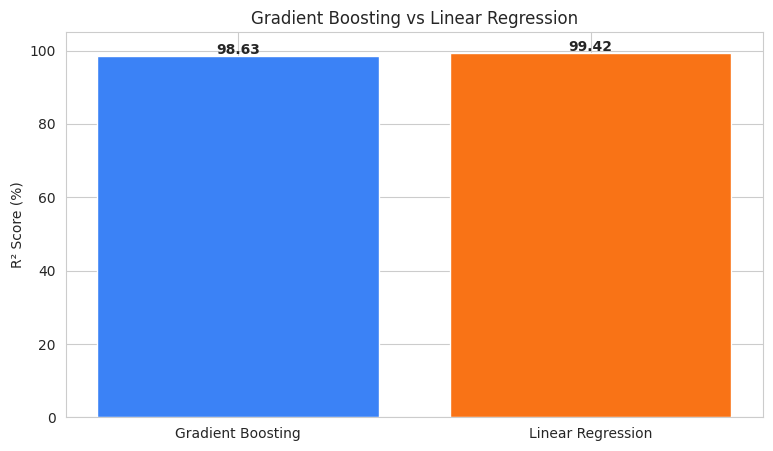

In [20]:
# Fig.2 style bar chart
plt.figure()
vals = [float(str(v).split()[0]) if isinstance(v, str) else v for v in table5["R2 (Test %)"]]
bars = plt.bar(table5["Model"], table5["R2 (Test %)"], color=['#3b82f6','#f97316'])
for b, v in zip(bars, table5["R2 (Test %)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.5, f"{v}", ha='center', fontweight='bold')
plt.ylabel("R² Score (%)"); plt.title("Gradient Boosting vs Linear Regression"); plt.ylim(0,105)
plt.show()


## 12. Feature Importance Analysis (Table VI / Fig.3 equivalent)

In [21]:
gbr_importance = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)
top10_gbr = gbr_importance.head(10)

table6 = top10_gbr.reset_index()
table6.columns = ["Feature","Importance Score"]
table6["Importance Score"] = table6["Importance Score"].round(3)
table6


,Feature,Importance Score
0,InternetFacl_Avail_bin,0.554
1,Electricity_bin,0.161
2,ChemLabCond_q,0.097
3,ComLabYn_bin,0.067
4,BioLabCond_q,0.041
5,FuncDrinkingWater_bin,0.024
6,Teacher_Tot,0.018
7,ClassRoom_Tot,0.011
8,ScienceKitAvail,0.008
9,smart_class_tv_func,0.004


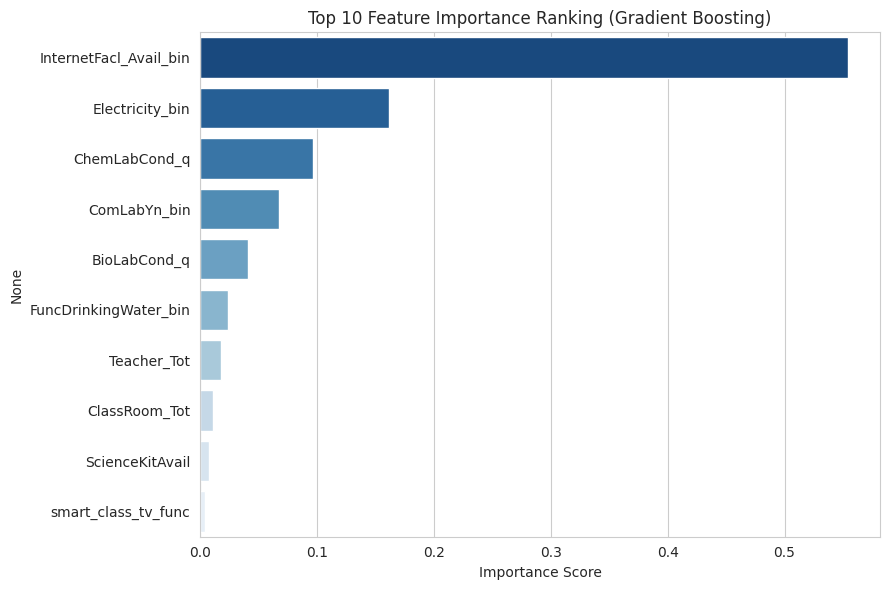

In [22]:
plt.figure(figsize=(9,6))
sns.barplot(x=top10_gbr.values, y=top10_gbr.index, palette='Blues_r')
plt.xlabel("Importance Score"); plt.title("Top 10 Feature Importance Ranking (Gradient Boosting)")
plt.tight_layout(); plt.show()


## 13. Final Summary — All Algorithms

In [23]:
print("="*70)
print("CLASSIFICATION MODELS (Test Set, 70/30 split)")
print("="*70)
display(table1)

print("\n" + "="*70)
print("CLASSIFICATION MODELS — 5-FOLD CROSS-VALIDATION")
print("="*70)
display(table2)

print("\n" + "="*70)
print(f"BEST MODEL FOLD-WISE DETAIL: {best_model_name}")
print("="*70)
display(table3)

print("\n" + "="*70)
print("DEEP LEARNING: 1D-CNN")
print("="*70)
display(table4)

print("\n" + "="*70)
print("REGRESSION MODELS (Readiness Score prediction)")
print("="*70)
display(table5)

print("\n" + "="*70)
print("TOP 10 FEATURES BY IMPORTANCE")
print("="*70)
display(table6)


CLASSIFICATION MODELS (Test Set, 70/30 split)


,Model,Acc (%),Precision,Recall,F1-Score
0,Random Forest Classifier,97.03,97.04,97.03,97.03
1,Support Vector Machine (SVM),96.44,96.47,96.44,96.44
2,Logistic Regression,96.14,96.18,96.14,96.14
3,Decision Tree Classifier,95.25,95.25,95.25,95.25
4,K-Nearest Neighbors (KNN),93.47,93.62,93.47,93.47
5,Naive Bayes (Bernoulli),82.49,83.49,82.49,82.37
6,Gaussian Naive Bayes,82.20,85.60,82.20,81.77



CLASSIFICATION MODELS — 5-FOLD CROSS-VALIDATION


,Model,Test Acc (%),CV Mean (%),CV Std (%),Precision,F1
0,Random Forest Classifier,97.03,97.77,0.85,0.9704,0.9703
1,Support Vector Machine (SVM),96.44,97.15,0.45,0.9647,0.9644
2,Logistic Regression,96.14,97.24,0.82,0.9618,0.9614
3,Decision Tree Classifier,95.25,96.17,1.04,0.9525,0.9525
4,K-Nearest Neighbors (KNN),93.47,95.99,1.64,0.9362,0.9347
5,Naive Bayes (Bernoulli),82.49,85.30,1.85,0.8349,0.8237
6,Gaussian Naive Bayes,82.20,82.09,2.10,0.8560,0.8177



BEST MODEL FOLD-WISE DETAIL: Random Forest Classifier


...

,Split,Accuracy (%),Precision,Recall,F1-Score,MAE,RMSE,R2 Score
0,Train Set,99.49,0.995,0.995,0.995,0.0113,0.0560,0.9875
1,Validation Set,97.63,0.977,0.976,0.976,0.0326,0.1405,0.9211
2,Test Set,97.04,0.970,0.970,0.970,0.0337,0.1568,0.9016



REGRESSION MODELS (Readiness Score prediction)


,Model,R2 (Test %),R2 (CV Mean ± Std %),MAE,RMSE
0,Gradient Boosting,98.63,99.00 ± 0.45,0.6903,1.6703
1,Linear Regression,99.42,99.41 ± 0.21,0.4136,1.0851



TOP 10 FEATURES BY IMPORTANCE


,Feature,Importance Score
0,InternetFacl_Avail_bin,0.554
1,Electricity_bin,0.161
2,ChemLabCond_q,0.097
3,ComLabYn_bin,0.067
4,BioLabCond_q,0.041
5,FuncDrinkingWater_bin,0.024
6,Teacher_Tot,0.018
7,ClassRoom_Tot,0.011
8,ScienceKitAvail,0.008
9,smart_class_tv_func,0.004


In [24]:
# Save everything to CSV for your report/appendix
table1.to_csv("table1_classification_performance.csv", index=False)
table2.to_csv("table2_classification_cv.csv", index=False)
table3.to_csv("table3_best_model_folds.csv", index=False)
table4.to_csv("table4_cnn_performance.csv", index=False)
table5.to_csv("table5_regression_performance.csv", index=False)
table6.to_csv("table6_feature_importance.csv", index=False)
print("All result tables saved as CSV files in the Colab working directory.")


All result tables saved as CSV files in the Colab working directory.
